# Keyword x colour overview

Run `mtg-analysis fetch` and `mtg-analysis build` first — this notebook only reads the
normalized parquet tables.

Every rate here is reported with the denominator behind it, and every share states the
weighting scheme it used. `fractional` splits a multicolour card evenly across its colours
(shares sum to 100%); `inclusive` counts it fully for each colour ("any card touching red").

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

from mtg_analysis.analysis.db import get_connection
from mtg_analysis.analysis.design_volume import design_volume, plot_design_volume
from mtg_analysis.analysis.heatmap import (
    keyword_color_matrix,
    pivot_matrix,
    plot_keyword_color_heatmap,
)
from mtg_analysis.analysis.timeseries import keyword_timeseries, plot_keyword_timeseries
from mtg_analysis.config import load_config
from mtg_analysis.metrics.core import color_share, penetration_rate, trend_report

config = load_config("../config/config.yaml")
con = get_connection("../" / config.paths.processed_dir, config.periods)
con.execute("SELECT COUNT(*) AS cards FROM cards").pl()

cards
i64
38633


## 1. Keyword x colour heatmap (deliverable 1)

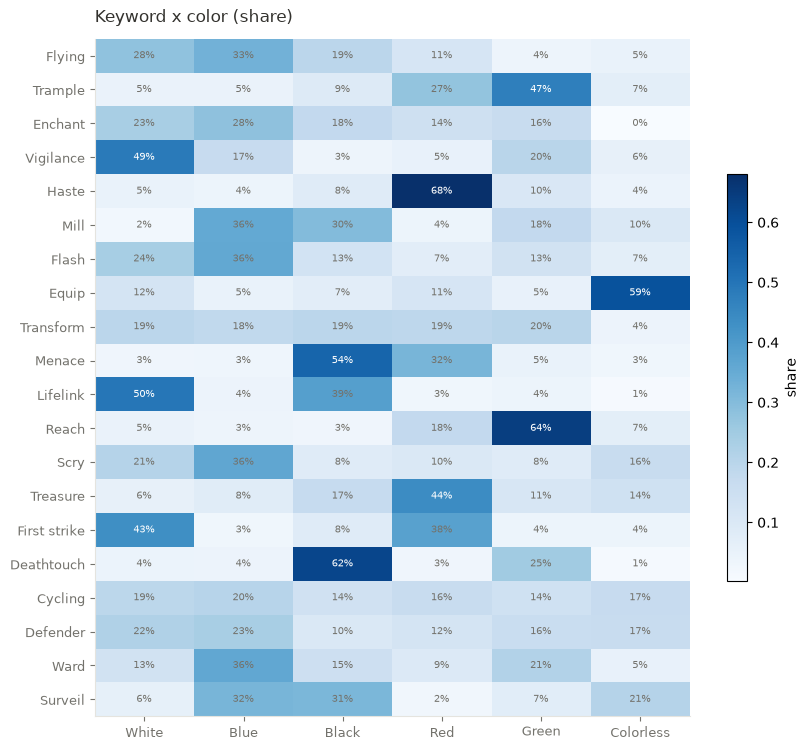

keyword,W,U,B,R,G,C
str,f64,f64,f64,f64,f64,f64
"""Flying""",922.0,1107.0,660.0,440.0,183.0,134.0
"""Trample""",80.0,82.0,124.0,318.0,511.0,63.0
"""Enchant""",277.0,329.0,208.0,166.0,192.0,3.0
"""Vigilance""",417.0,166.0,56.0,87.0,192.0,39.0
"""Haste""",68.0,52.0,83.0,474.0,92.0,25.0
…,…,…,…,…,…,…
"""Deathtouch""",29.0,28.0,231.0,21.0,93.0,4.0
"""Cycling""",72.0,76.0,54.0,63.0,54.0,59.0
"""Defender""",60.0,67.0,28.0,35.0,44.0,44.0


In [2]:
matrix = keyword_color_matrix(con, top_n=20)
plot_keyword_color_heatmap(matrix, value="share")
plt.show()
pivot_matrix(matrix, value="raw_count")

## 2. One keyword's headline numbers

Both weightings are printed side by side rather than silently picking one.

In [3]:
keyword, color = "Double strike", "R"
for weighting in ("fractional", "inclusive"):
    share = color_share(con, keyword, color, weighting=weighting)
    rate = penetration_rate(con, keyword, color, weighting=weighting)
    print(f"{weighting:>10}: {color} holds {share:.1%} of {keyword}; "
          f"{rate:.2%} of {color} cards carry it")

fractional: R holds 41.8% of Double strike; 0.86% of R cards carry it
 inclusive: R holds 39.0% of Double strike; 0.91% of R cards carry it


## 3. Trend over sets (deliverable 2)

`trend_report` returns raw count, colour share and penetration rate together — they can
move in opposite directions, and reading one without the others is the main way to get a
claim wrong here.

In [4]:
trend_report(con, "Haste", "R").tail(10)

period,period_order,period_released_at,raw_count,color_share,penetration_rate,color_total,keyword,color,weighting,set_type_filter
str,i64,date,"decimal[38,0]",f64,f64,f64,str,str,str,str
"""adsk..fj25""",48,2024-09-27,15,0.694444,0.086068,145.233333,"""Haste""","""R""","""fractional""","""paper_only"""
"""j25..tdft""",49,2024-11-15,9,0.716667,0.131902,54.333333,"""Haste""","""R""","""fractional""","""paper_only"""
"""tdrc..afin""",50,2025-02-14,11,0.763889,0.096457,95.033333,"""Haste""","""R""","""fractional""","""paper_only"""
"""fic..aa2""",51,2025-06-13,9,0.511111,0.055744,137.533333,"""Haste""","""R""","""fractional""","""paper_only"""
"""yeoe..ftla""",52,2025-08-19,6,0.45,0.103713,26.033333,"""Haste""","""R""","""fractional""","""paper_only"""
"""jtla..ecl""",53,2025-11-21,7,0.814286,0.037545,151.816667,"""Haste""","""R""","""fractional""","""paper_only"""
"""tecc..pf26""",54,2026-01-23,4,0.45,0.054878,49.2,"""Haste""","""R""","""fractional""","""paper_only"""
"""asos..msc""",55,2026-04-24,24,0.641667,0.09307,206.833333,"""Haste""","""R""","""fractional""","""paper_only"""
"""msh..tfra""",56,2026-06-26,13,0.65625,0.101449,103.5,"""Haste""","""R""","""fractional""","""paper_only"""


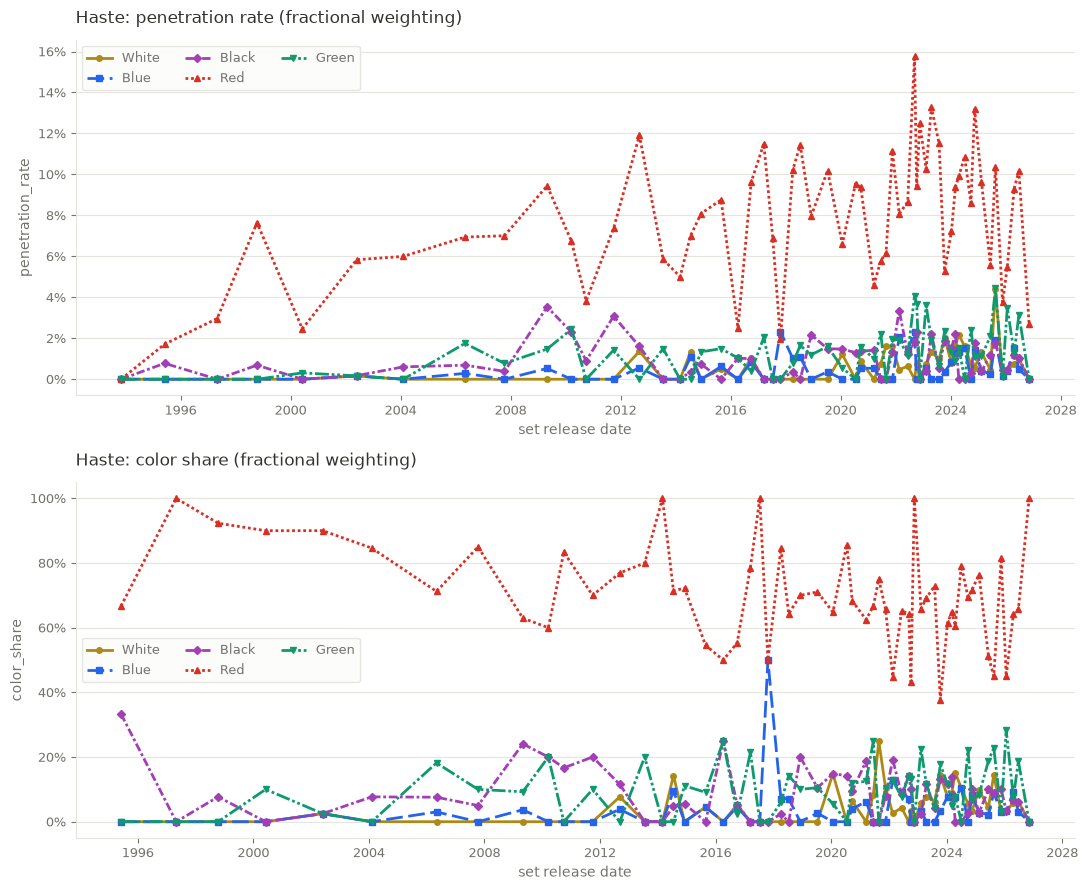

In [5]:
series = keyword_timeseries(con, "Haste", colors=["W", "U", "B", "R", "G"])
fig, axes = plt.subplots(2, 1, figsize=(11, 9))
plot_keyword_timeseries(series, metric="penetration_rate", ax=axes[0])
plot_keyword_timeseries(series, metric="color_share", ax=axes[1])
fig.tight_layout()
plt.show()

## 4. Design volume context (deliverable 8)

The denominator behind every rate above. Always show this next to a raw-count chart.

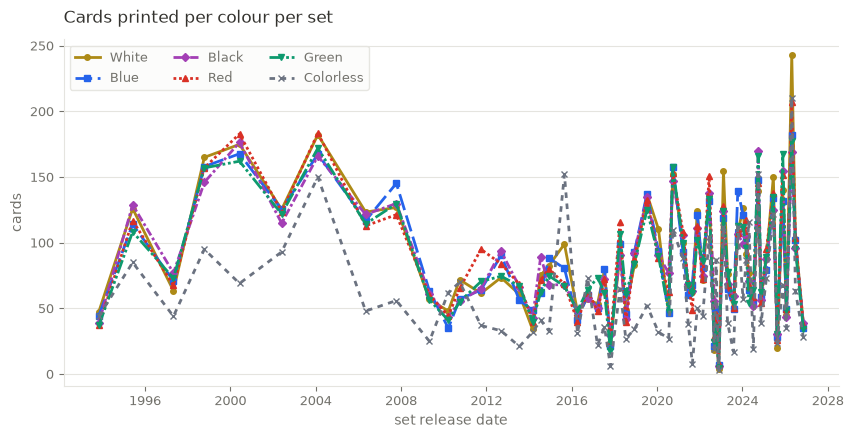

period,period_order,period_released_at,color,total_cards
str,i64,date,str,f64
"""mbc..ttrk""",57,2026-11-09,"""C""",28.0
"""mbc..ttrk""",57,2026-11-09,"""G""",34.066667
"""mbc..ttrk""",57,2026-11-09,"""R""",37.233333
"""mbc..ttrk""",57,2026-11-09,"""U""",35.4
"""mbc..ttrk""",57,2026-11-09,"""W""",37.733333


In [6]:
volume = design_volume(con)
plot_design_volume(volume)
plt.show()
volume.tail()

## Smoothing noisy sets

Small sets make per-set rates jumpy. Group consecutive sets without rebuilding anything:

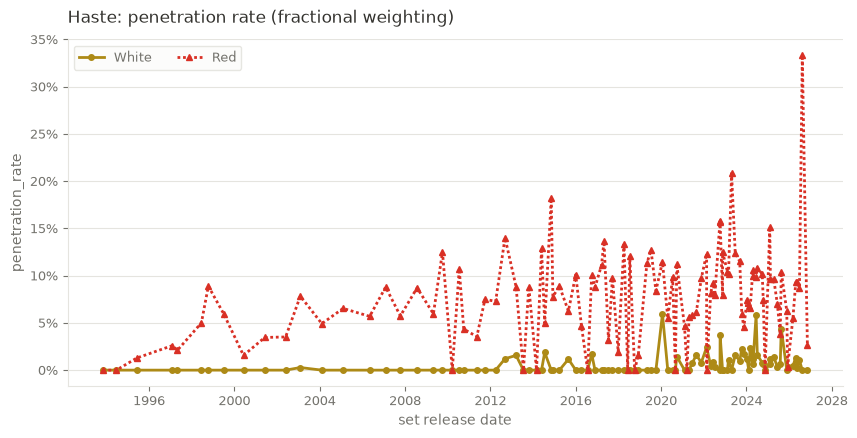

In [7]:
from mtg_analysis.analysis.db import set_period_config
from mtg_analysis.config import PeriodGroupConfig

set_period_config(con, PeriodGroupConfig(mode="rolling_sets", group_size=5))
plot_keyword_timeseries(keyword_timeseries(con, "Haste", colors=["R", "W"]))
plt.show()
set_period_config(con, config.periods)